In [1]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import timm
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# 配置
BASE_DIR = "/root/autodl-tmp/tongue_project"
DATA_DIR = os.path.join(BASE_DIR, "data/upload")
WEIGHT_PATH = "best_Swin-Base.pth" # 确保路径正确
TARGET_LABELS = ['hongshe', 'zishe', 'pangdashe', 'shoushe', 'hongdianshe', 
                 'liewenshe', 'chihenshe', 'baitaishe', 'huangtaishe', 'huataishe']
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 预处理函数 (必须与 Swin-original 训练时完全一致)
def preprocess_image_original(img_path, mask_path):
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if img.shape[:2] != mask.shape[:2]:
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
    
    # Crop & Padding
    coords = np.column_stack(np.where(mask > 0))
    ymin, xmin = coords.min(axis=0); ymax, xmax = coords.max(axis=0)
    side = max(ymax - ymin, xmax - xmin)
    cy, cx = (ymin + ymax) // 2, (xmin + xmax) // 2
    
    avg_col = img[mask > 0].mean(axis=0).tolist() if (mask > 0).any() else [127, 127, 127]
    canvas = np.full((side, side, 3), avg_col, dtype=np.uint8)
    h, w = img.shape[:2]
    y1, y2, x1, x2 = max(0, cy-side//2), min(h, cy+side//2), max(0, cx-side//2), min(w, cx+side//2)
    dy1, dx1 = y1-(cy-side//2), x1-(cx-side//2)
    canvas[dy1:dy1+(y2-y1), dx1:dx1+(x2-x1)] = img[y1:y2, x1:x2]
    
    # 遮罩画布
    m_canvas = np.zeros((side, side), dtype=np.uint8)
    m_canvas[dy1:dy1+(y2-y1), dx1:dx1+(x2-x1)] = mask[y1:y2, x1:x2]
    
    # 高斯模糊背景
    img_blur = cv2.GaussianBlur(canvas, (25, 25), 15)
    mask_soft = cv2.GaussianBlur(m_canvas, (15, 15), 0) / 255.0
    img_f = (canvas * mask_soft[...,None] + img_blur * (1.0 - mask_soft[...,None])).astype(np.uint8)
    
    return cv2.cvtColor(img_f, cv2.COLOR_BGR2RGB)

In [2]:
import math

# 1. 加载模型
model = timm.create_model('swin_base_patch4_window12_384', pretrained=False, num_classes=len(TARGET_LABELS))
model.load_state_dict(torch.load(WEIGHT_PATH, map_location=DEVICE))
model = model.to(DEVICE).eval()

# 2. 定位正确的 Target Layer
# 对于 timm 中的 Swin，最稳定且包含丰富空间信息的层是最后一个 Stage 的最后一个 Block
target_layers = [model.layers[-1].blocks[-1].norm2]

# 3. 核心修复：Swin 专属维度转换函数
def swin_reshape_transform(tensor):
    """
    将 Swin 的输出形状转换回 Grad-CAM 认识的形状
    支持 (B, H, W, C) 或 (B, L, C) -> (B, C, H, W)
    """
    if tensor.ndim == 3:
        B, L, C = tensor.shape
        H = W = int(math.sqrt(L))
        tensor = tensor.reshape(B, H, W, C)
    
    # 关键：将通道 C 从最后一个维度移到第二个维度
    # (B, H, W, C) -> (B, C, H, W)
    result = tensor.permute(0, 3, 1, 2)
    return result

# 4. 初始化带有维度转换的 Grad-CAM++
cam = GradCAMPlusPlus(
    model=model, 
    target_layers=target_layers,
    reshape_transform=swin_reshape_transform
)

print("Model and Swin-specific Grad-CAM++ Engine Ready.")

Model and Swin-specific Grad-CAM++ Engine Ready.


In [3]:
# 加载测试集信息
test_df = pd.read_csv(os.path.join(DATA_DIR, "test-labels.csv"))
test_df['id'] = test_df['filename'].apply(lambda x: os.path.splitext(str(x).split('-')[-1])[0].strip())
test_mask_dir = os.path.join(DATA_DIR, "images_test_v2_mask_filtered")

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 存储每个标签的候选图：{label: [(prob, img_tensor, rgb_img, filename), ...]}
candidates = {label: [] for label in TARGET_LABELS}

print("Inference and filtering top samples...")
for idx, row in test_df.iterrows():
    base_id = row['id']
    img_path = os.path.join(DATA_DIR, "test/images", base_id + ".jpg")
    if not os.path.exists(img_path): img_path = img_path.replace(".jpg", ".JPG")
    mask_path = os.path.join(test_mask_dir, base_id + "_best_mask.jpg")
    
    if not (os.path.exists(img_path) and os.path.exists(mask_path)): continue
    
    # 预处理
    rgb_img = preprocess_image_original(img_path, mask_path)
    input_tensor = transform(rgb_img).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        output = torch.sigmoid(model(input_tensor)).cpu().numpy()[0]
    
    for i, label in enumerate(TARGET_LABELS):
        # 准则：Ground Truth 为 1 且预测概率高
        gt = row[label]
        if gt == 1:
            candidates[label].append((output[i], input_tensor, rgb_img, base_id))

# 排序并取前 5
for label in TARGET_LABELS:
    candidates[label] = sorted(candidates[label], key=lambda x: x[0], reverse=True)[:5]

print("Top samples identified for each label.")

Inference and filtering top samples...
Top samples identified for each label.


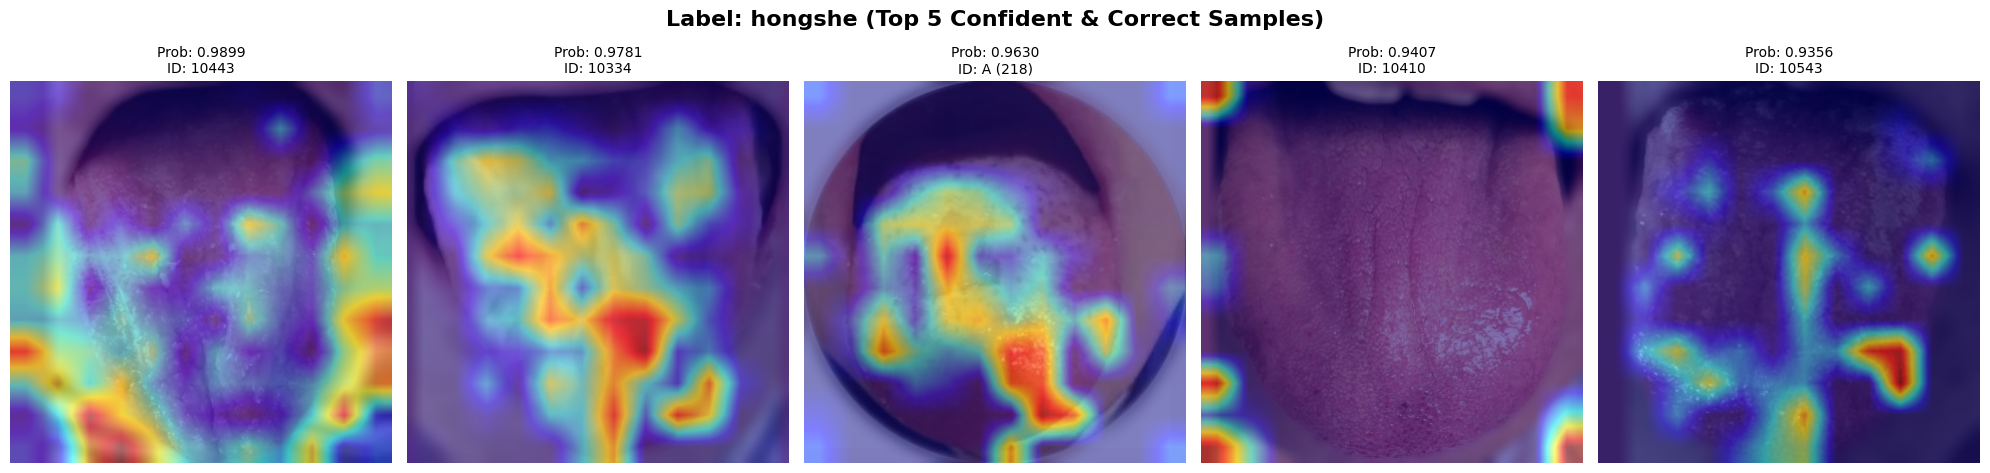

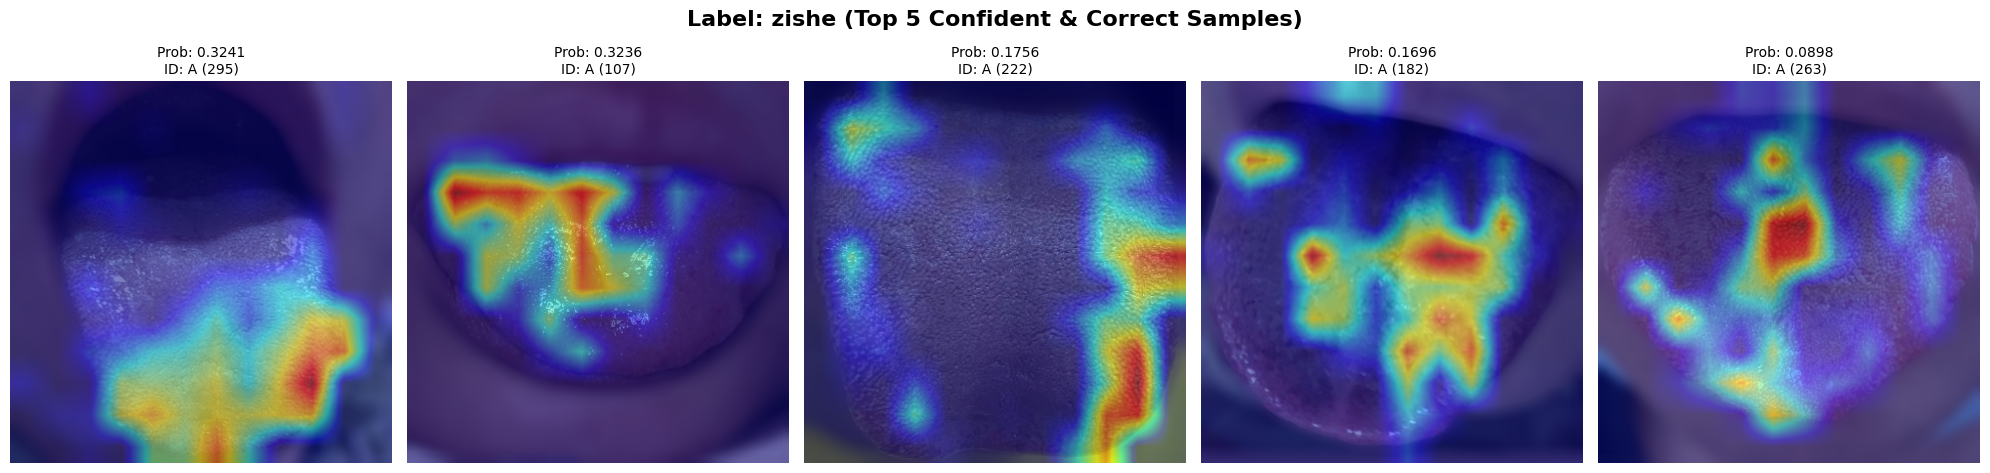

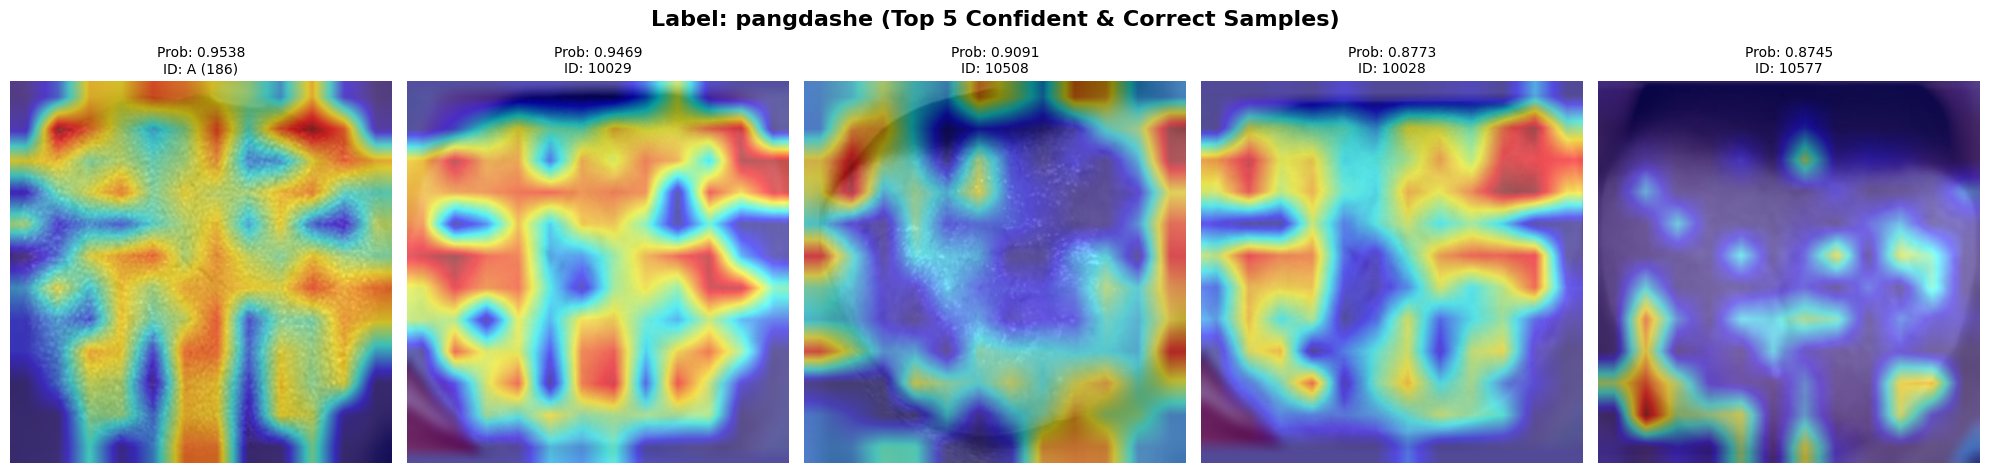

In [ ]:
for label_idx, label in enumerate(TARGET_LABELS):
    items = candidates[label]
    if not items: continue
    
    plt.figure(figsize=(20, 5))
    plt.suptitle(f"Label: {label} (Top 5 Confident & Correct Samples)", fontsize=16, fontweight='bold')
    
    for i, (prob, input_tensor, rgb_img, base_id) in enumerate(items):
        # 计算该类别的 Grad-CAM++
        targets = [ClassifierOutputTarget(label_idx)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
        
        # 将热力图叠加到原图（需要将 rgb_img 缩放到 384x384 匹配）
        img_resized = cv2.resize(rgb_img, (384, 384))
        img_float = img_resized.astype(np.float32) / 255.0
        visualization = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)
        
        # 绘图
        plt.subplot(1, 5, i + 1)
        plt.imshow(visualization)
        plt.title(f"Prob: {prob:.4f}\nID: {base_id}", fontsize=10)
        plt.axis('off')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()